In [1]:
from typing import Dict, TypedDict, List, Union, Annotated, Sequence
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage, ToolMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool

load_dotenv()


c:\Users\ka448\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


True

In [ ]:
@tool
def add(a: int, b: int):
    """Addition tool that adds two numbers together."""
    print(f"Adding {a} and {b}")
    return a + b
tools = [add]

llm = ChatOpenAI(model="gpt-5.4-nano").bind_tools(tools)

In [ ]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [ ]:
def agent_node(state: AgentState) -> AgentState:

    system_prompt = SystemMessage(content="You are a helpful assistant that can use tools to answer questions.")
    response = llm.invoke([system_prompt] + state["messages"])
    print(f"LLM response: {response} agent_node")
    return {"messages": [response]}

In [5]:
def decider(state: AgentState) -> AgentState:
    if "add" not in state["messages"]:
        return "END"
    elif "add" in state["messages"]:
        response = llm.invoke(state["messages"])
        return "Continue"
    
def tool_node(state: AgentState) -> AgentState:
    response = llm.invoke(state["messages"])
    print(f"LLM response: {response} tool_node")
    return state

In [6]:
main_graph = StateGraph(AgentState)
main_graph.add_node("Agent", agent_node)
main_graph.add_node("Tool", tool_node)
main_graph.add_edge("Agent", "Tool")
main_graph.add_conditional_edges("Tool", decider, {"END": END, "Continue": "Agent"})
main_graph.set_entry_point("Agent")
main_graph.set_finish_point("Tool")


x = main_graph.compile()


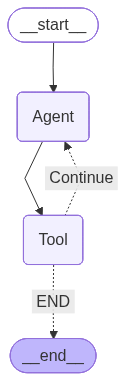

In [7]:
x

In [8]:
result = x.invoke({"messages": [HumanMessage(content="What is 2 + 2? use the add tool (example_tool) to calculate the answer")]})

LLM response: content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 150, 'total_tokens': 171, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-nano-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DO6PfCKDgGOXGNtp9sAHC9JX3tghS', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019d309a-066e-7c50-8f81-aaa3f3528ebc-0' tool_calls=[{'name': 'example_tool', 'args': {'a': 2, 'b': 2}, 'id': 'call_QEcXMgmAYDYKE4r3gEGtAbgU', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 150, 'output_tokens': 21, 'total_tokens': 171, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}} agent_node
LLM response:

In [10]:
result

{'messages': [HumanMessage(content='What is 2 + 2? use the add tool to calculate the answer', additional_kwargs={}, response_metadata={}, id='d4f2e393-90d5-4d69-be35-26cc37ed765c')]}